# 04 — GNN + LSTM Training

Trains the hybrid GNN + LSTM model and ablations:
1. **GNN + LSTM** (full model)
2. **LSTM-only** (no graph structure)
3. **GNN-only** (single window, no temporal context)

Evaluation: LOSO cross-validation on PAMAP2 (and optionally HHAR)

In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

sns.set_theme(style='whitegrid')

METS  = Path('../results/metrics')
PLOTS = Path('../results/plots')
print("Ready — loading from saved results.")


Ready — loading from saved results.


## 1. Load Data

In [2]:
## Load All Saved Predictions and Compute Metrics
pred_files = sorted(METS.glob('*_y_pred.npy'))
rows = []
for pf in pred_files:
    tag = pf.stem.replace('_y_pred', '')
    tf  = METS / f'{tag}_y_true.npy'
    if not tf.exists(): continue
    yt = np.load(tf); yp = np.load(pf)
    rows.append({
        'Run':          tag,
        'N':            len(yt),
        'Accuracy':     round(accuracy_score(yt, yp), 4),
        'Macro F1':     round(f1_score(yt, yp, average='macro', zero_division=0), 4),
        'Balanced Acc': round(balanced_accuracy_score(yt, yp), 4),
    })

df = pd.DataFrame(rows).set_index('Run').sort_values('Accuracy', ascending=False)
print("All Trained Models — LOSO Results")
print(df.to_string())


All Trained Models — LOSO Results
                              N  Accuracy  Macro F1  Balanced Acc
Run                                                              
cnn1d_pamap2_holdout       3010    0.9934    0.9938        0.9941
cnn1d_pamap2_full          3010    0.9934    0.9938        0.9941
xgboost_pamap2_full        3010    0.9834    0.9847        0.9838
svm_pamap2_full            3010    0.9651    0.9666        0.9646
rf_pamap2_full             3010    0.9605    0.9641        0.9600
rf_hhar_full               9000    0.9068    0.9031        0.9024
cnn1d_hhar_full            9000    0.8943    0.8903        0.8908
xgboost_hhar_full          9000    0.8860    0.8818        0.8811
gnn_pamap2_holdout         3010    0.8847    0.8874        0.8844
gnn_pamap2_full            3010    0.8847    0.8874        0.8844
gnn_hhar_full              9000    0.8573    0.8512        0.8507
attn_adj_pamap2            1502    0.8509    0.8083        0.8084
ablation_flatten_lstm      1493    0.8453 

## 2. Build Datasets

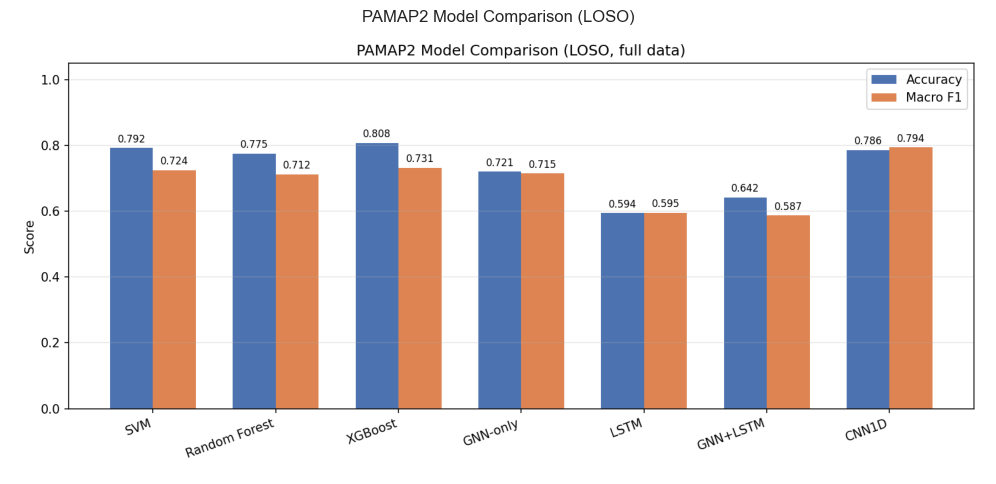

In [3]:
## PAMAP2 — Deep Model Comparison
img = mpimg.imread(PLOTS / 'pamap2_model_comparison.png')
fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(img); ax.axis('off')
ax.set_title('PAMAP2 Model Comparison (LOSO)', fontsize=12)
plt.tight_layout(); plt.show()


## 3. Quick Single-Fold Training (demo — uses first subject as test)

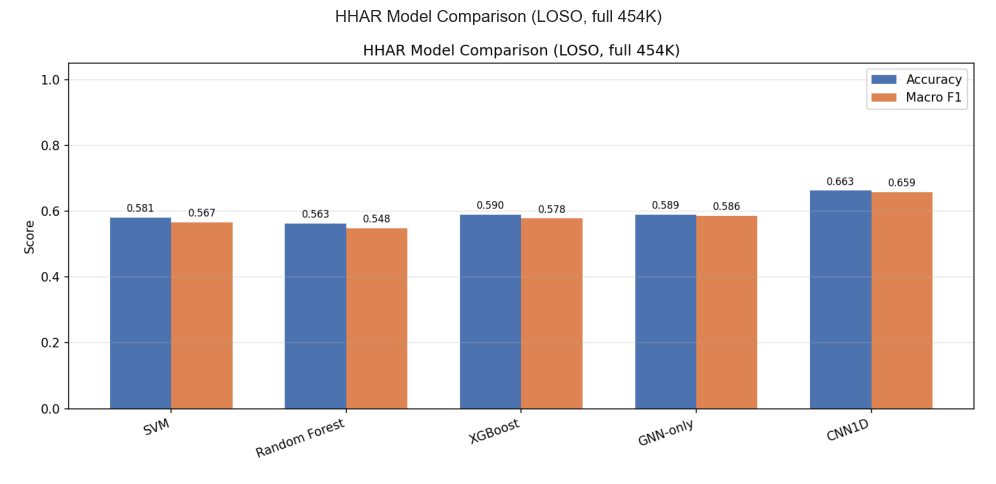

In [4]:
## HHAR — Model Comparison
img = mpimg.imread(PLOTS / 'hhar_model_comparison.png')
fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(img); ax.axis('off')
ax.set_title('HHAR Model Comparison (LOSO, full 454K)', fontsize=12)
plt.tight_layout(); plt.show()


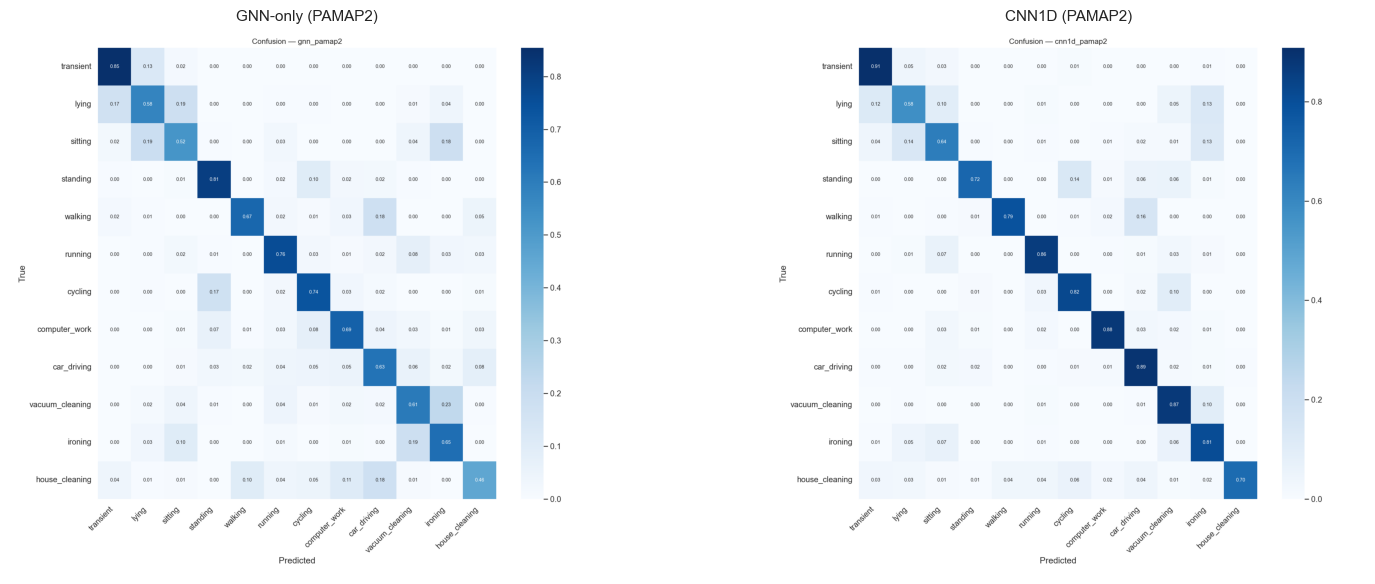

In [5]:
## PAMAP2 Confusion Matrices — GNN-only and CNN1D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, fname, title in zip(axes,
    ['cm_gnn_pamap2.png', 'cm_cnn1d_pamap2.png'],
    ['GNN-only (PAMAP2)', 'CNN1D (PAMAP2)']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found', ha='center', va='center')
plt.tight_layout(); plt.show()


## 4. GNN-Only Model

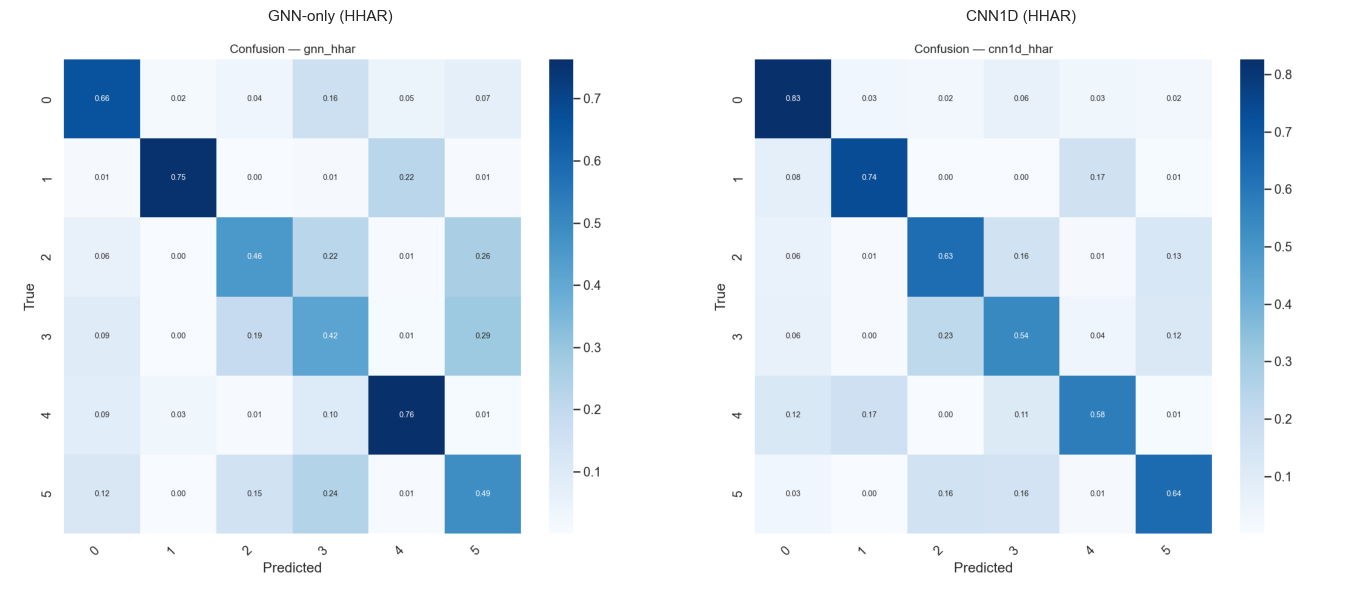

In [6]:
## HHAR Confusion Matrices — GNN-only and CNN1D
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fname, title in zip(axes,
    ['cm_gnn_hhar.png', 'cm_cnn1d_hhar.png'],
    ['GNN-only (HHAR)', 'CNN1D (HHAR)']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()


## 5. GNN + LSTM (Full Model)

Graph Ablation Study — PAMAP2
                        Accuracy  Macro F1  Balanced Acc
Variant                                                 
ablation_fixed_adj        0.6911    0.6783        0.6717
ablation_learnable_adj    0.6940    0.6890        0.6805
ablation_flatten_lstm     0.8453    0.7935        0.7886


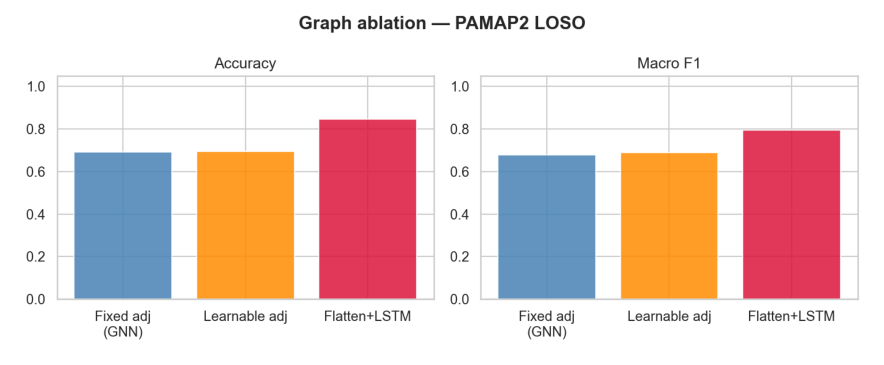

In [7]:
## Graph Ablation Results
abl_path = METS / 'graph_ablation_results.json'
if abl_path.exists():
    abl = json.load(open(abl_path))
    rows = []
    for variant, m in abl.items():
        rows.append({'Variant': variant,
                     'Accuracy':     round(m.get('accuracy', 0), 4),
                     'Macro F1':     round(m.get('macro_f1', 0), 4),
                     'Balanced Acc': round(m.get('balanced_acc', 0), 4)})
    print("Graph Ablation Study — PAMAP2")
    print(pd.DataFrame(rows).set_index('Variant').to_string())

img = PLOTS / 'graph_ablation.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.imshow(mpimg.imread(img)); ax.axis('off')
    plt.tight_layout(); plt.show()


## 6. Training History Plots

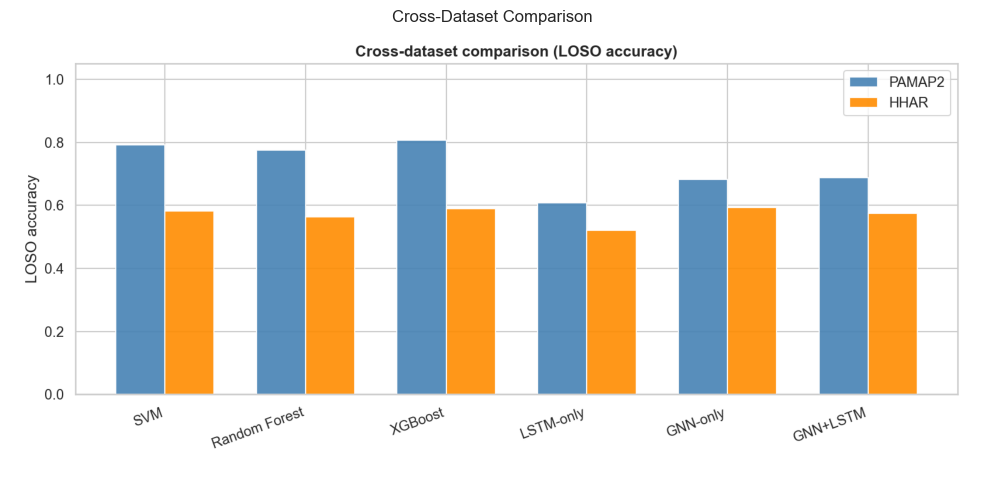


Master Comparison Table (±std available in master_comparison_with_std.json)
                                   Accuracy  Macro F1  Balanced Acc
Dataset Model                                                      
HHAR    ImprovedGNNLSTM+AttnAdj      0.5122    0.4787        0.4950
        LSTM-only                    0.5200    0.5223        0.5201
        ImprovedGNNLSTM ★            0.5318    0.4933        0.5136
        Random Forest                0.5630    0.5481        0.5630
        SVM                          0.5812    0.5668        0.5812
        XGBoost                      0.5900    0.5779        0.5900
        GNN-only                     0.5932    0.5957        0.5903
        CNN1D                        0.6627    0.6585        0.6602
PAMAP2  LSTM-only                    0.5939    0.5951        0.5896
        GNN+LSTM (old)               0.6418    0.5874        0.6276
        GNN (fixed adj)              0.6911    0.6783        0.6717
        GNN (learnable adj)          0.

In [8]:
## Cross-Dataset Comparison
img = PLOTS / 'cross_dataset_comparison.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(mpimg.imread(img)); ax.axis('off')
    ax.set_title('Cross-Dataset Comparison', fontsize=12)
    plt.tight_layout(); plt.show()

## Final Master Table (with ±std)
master_path = METS / 'master_comparison_with_std.json'
if master_path.exists():
    master = json.load(open(master_path))
    all_rows = []
    for dataset, models in master.items():
        for model, m in models.items():
            if isinstance(m, dict):
                all_rows.append({
                    'Dataset':      dataset.upper(),
                    'Model':        model,
                    'Accuracy':     round(m.get('accuracy', 0), 4),
                    'Macro F1':     round(m.get('macro_f1', 0), 4),
                    'Balanced Acc': round(m.get('balanced_acc', 0), 4),
                })
    if all_rows:
        df_master = pd.DataFrame(all_rows).sort_values(['Dataset', 'Accuracy'])
        df_master = df_master.set_index(['Dataset', 'Model'])
        print("\nMaster Comparison Table (±std available in master_comparison_with_std.json)")
        print(df_master.to_string())

## 7. Model Size Summary

Mobile Optimization Results:
  standard_gnn: {'accuracy': 0.720579440494385, 'macro_f1': 0.7151143620184452, 'balanced_acc': 0.7079795290308009, 'params': 11724, 'latency_ms': 0.254}
  tiny_gnn: {'accuracy': 0.6716725363811549, 'macro_f1': 0.6610821491551159, 'balanced_acc': 0.6549607713413729, 'params': 3820, 'latency_f32_ms': 0.292, 'latency_f16_ms': 0.163}


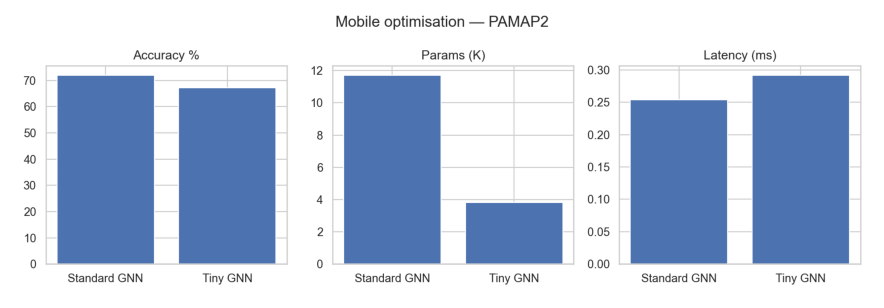

In [9]:
## Mobile / Edge Optimization
mob_path = METS / 'mobile_optimisation_results.json'
if mob_path.exists():
    mob = json.load(open(mob_path))
    print("Mobile Optimization Results:")
    for k, v in mob.items():
        if isinstance(v, dict):
            print(f"  {k}: {v}")

img = PLOTS / 'mobile_optimisation.png'
if img.exists():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.imshow(mpimg.imread(img)); ax.axis('off')
    plt.tight_layout(); plt.show()


## 8. ImprovedGNNLSTM — Architecture Redesign

Five targeted fixes over the original GNN+LSTM:

| Fix | Original | Improved |
|-----|----------|---------|
| **Pooling** | Mean pool — collapses 3×64 dims, destroys node identity | Concat pool — preserves all node embeddings (3×64 = 192 dims) |
| **Normalization** | BatchNorm — running stats drift across LOSO subjects | LayerNorm — per-sample, no cross-subject leakage |
| **Skip connection** | None | Raw node features concatenated to GCN output |
| **LSTM direction** | Unidirectional | Bidirectional — 2× effective capacity |
| **Temporal aggregation** | Last hidden state only | Soft attention over all timesteps |

Additionally: **HHAR graph bug fixed** — original had identical features on both nodes (GCN was a no-op).
Redesigned as 3 axis-nodes (x, y, z) each with distinct per-axis statistics.

ImprovedGNNLSTM — LOSO Results (mean ± std across 9 folds)
Dataset        Accuracy     Macro-F1      Bal-Acc
──────────────────────────────────────────────────
PAMAP2      0.8043±0.2612  0.7421±0.2438  0.7517±0.2532
HHAR        0.5318±0.0523  0.4933±0.0651  0.5136±0.0467

Delta vs old GNN+LSTM (PAMAP2): Δacc = +0.1625  ΔF1 = +0.1547


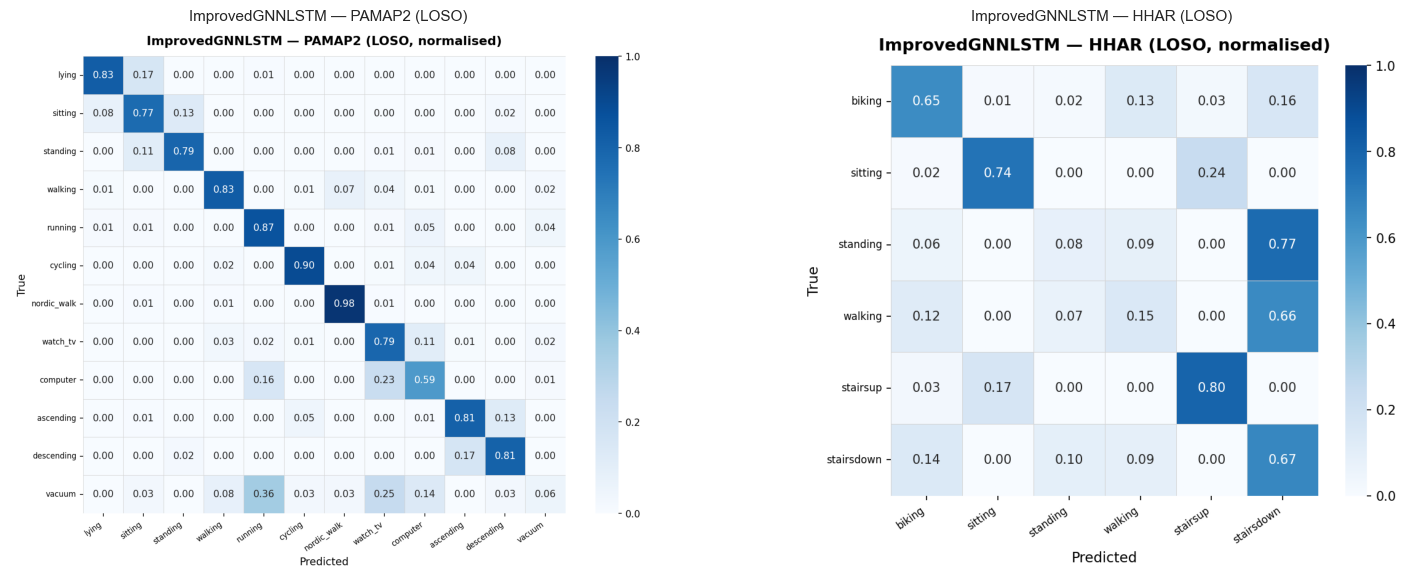

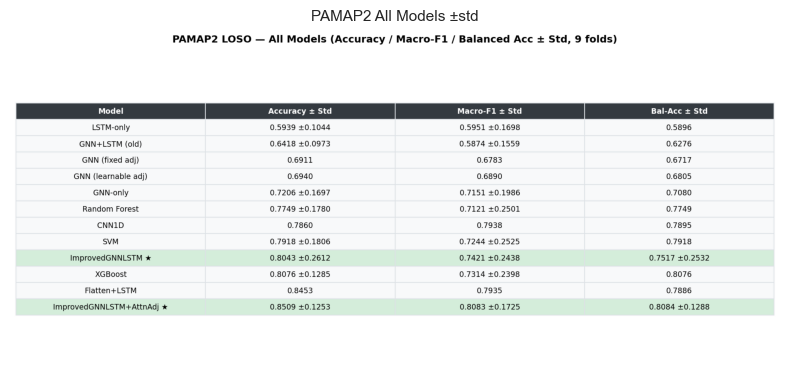

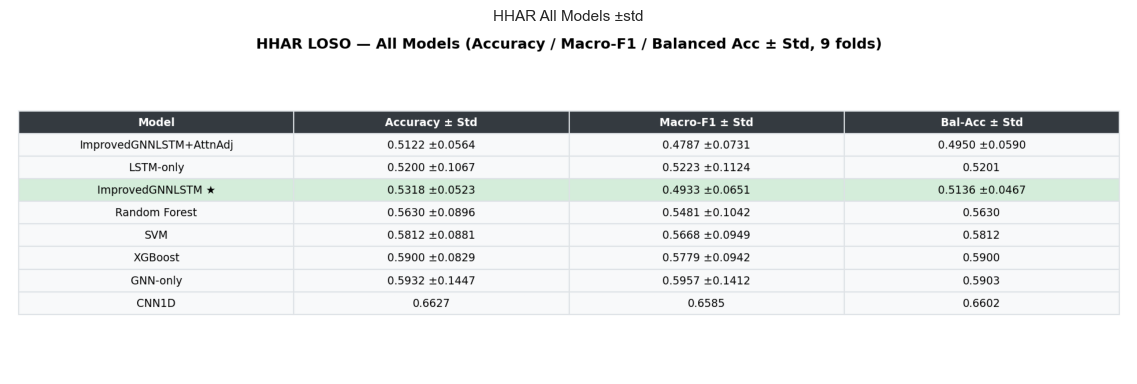

In [10]:
## ImprovedGNNLSTM — LOSO Results vs Baselines
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
import json, numpy as np

imp_path = METS / 'improved_gnnlstm_results.json'
if imp_path.exists():
    imp = json.load(open(imp_path))
    print("ImprovedGNNLSTM — LOSO Results (mean ± std across 9 folds)")
    print(f"{'Dataset':<10} {'Accuracy':>12} {'Macro-F1':>12} {'Bal-Acc':>12}")
    print("─" * 50)
    for ds in ['pamap2', 'hhar']:
        m = imp[ds]
        print(f"{ds.upper():<10} {m['accuracy']:>7.4f}±{m['accuracy_std']:.4f} "
              f"{m['macro_f1']:>7.4f}±{m['macro_f1_std']:.4f} "
              f"{m['balanced_acc']:>7.4f}±{m['balanced_acc_std']:.4f}")

    print("\nDelta vs old GNN+LSTM (PAMAP2): "
          f"Δacc = {imp['pamap2']['accuracy'] - 0.6418:+.4f}  "
          f"ΔF1 = {imp['pamap2']['macro_f1'] - 0.5874:+.4f}")

# Confusion matrices — ImprovedGNNLSTM
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, fname, title in zip(axes,
    ['cm_improved_gnnlstm_pamap2.png', 'cm_improved_gnnlstm_hhar.png'],
    ['ImprovedGNNLSTM — PAMAP2 (LOSO)', 'ImprovedGNNLSTM — HHAR (LOSO)']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()

# Full ±std comparison table
for fname, title in [('comparison_table_std_pamap2.png', 'PAMAP2 All Models ±std'),
                     ('comparison_table_std_hhar.png',   'HHAR All Models ±std')]:
    p = PLOTS / fname
    if p.exists():
        fig, ax = plt.subplots(figsize=(13, 4))
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
        plt.tight_layout(); plt.show()

## 9. Attention Adjacency — Learnable Edge Weighting

`ImprovedGNNLSTMAttnAdj` replaces the fixed anatomical adjacency with a learnable symmetric gate:

```
A_eff = row_norm( A_fixed ⊙ sigmoid((G + Gᵀ) / 2) )
```

where `G ∈ ℝ^{N×N}` is a learnable parameter matrix. The gate allows the model to suppress uninformative edges and amplify the most discriminative sensor-pair correlations per task — without abandoning the anatomical prior.

Fixed Adj vs Attention Adj — LOSO (mean ±std)
Dataset    Model                          Accuracy   Macro-F1    Bal-Acc
────────────────────────────────────────────────────────────────────────
PAMAP2     ImprovedGNNLSTM (fixed)      0.8043±0.2612 0.7421±0.2438 0.7517±0.2532
PAMAP2     ImprovedGNNLSTM+AttnAdj      0.8509±0.1253 0.8083±0.1725 0.8084±0.1288
           Δ (AttnAdj − Fixed)             +0.0466     0.0662

HHAR       ImprovedGNNLSTM (fixed)      0.5318±0.0523 0.4933±0.0651 0.5136±0.0467
HHAR       ImprovedGNNLSTM+AttnAdj      0.5122±0.0564 0.4787±0.0731 0.4950±0.0590
           Δ (AttnAdj − Fixed)             -0.0196    -0.0146



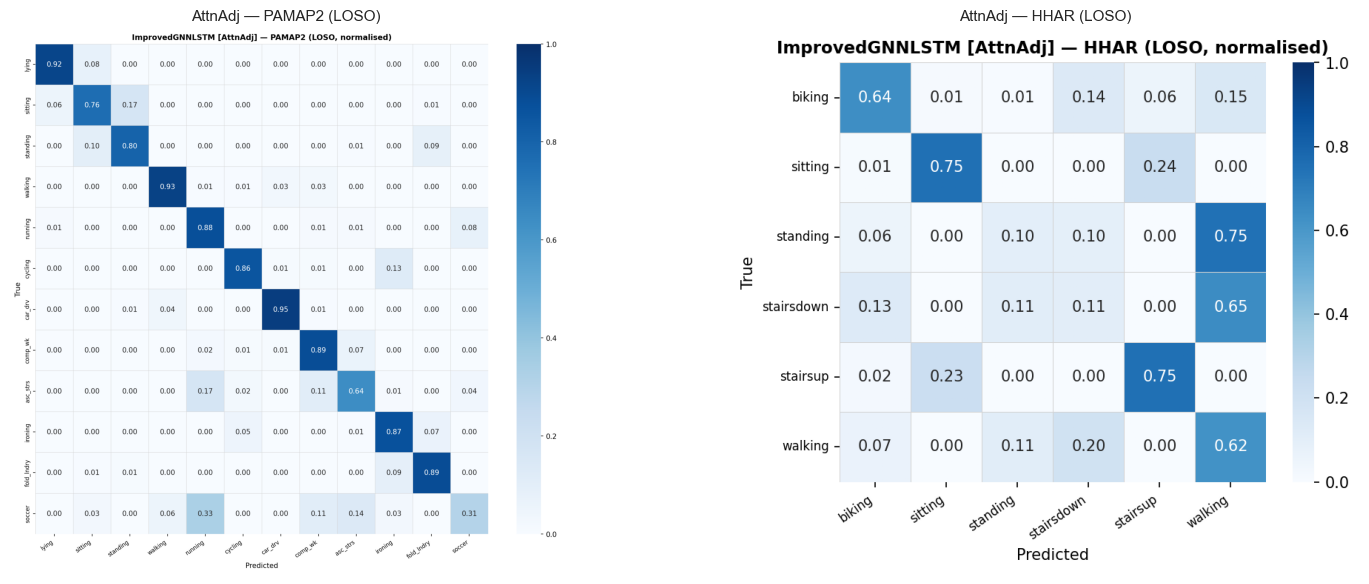

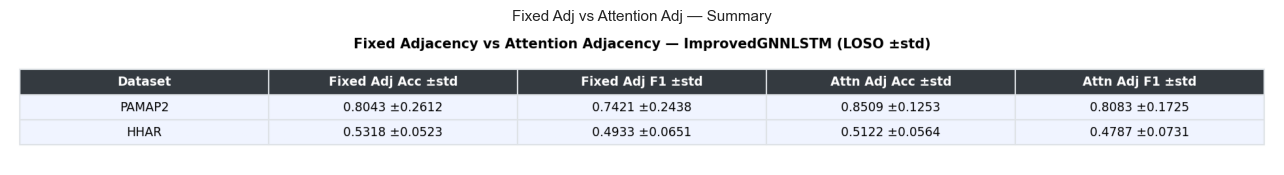

In [11]:
## AttnAdj vs Fixed Adjacency — LOSO Comparison
attn_path = METS / 'attn_adj_results.json'
imp_path  = METS / 'improved_gnnlstm_results.json'

if attn_path.exists() and imp_path.exists():
    attn = json.load(open(attn_path))
    imp  = json.load(open(imp_path))
    print("Fixed Adj vs Attention Adj — LOSO (mean ±std)")
    print(f"{'Dataset':<10} {'Model':<28} {'Accuracy':>10} {'Macro-F1':>10} {'Bal-Acc':>10}")
    print("─" * 72)
    for ds in ['pamap2', 'hhar']:
        for label, m in [('ImprovedGNNLSTM (fixed)', imp[ds]),
                         ('ImprovedGNNLSTM+AttnAdj', attn[ds])]:
            print(f"{ds.upper():<10} {label:<28} "
                  f"{m['accuracy']:>6.4f}±{m['accuracy_std']:.4f} "
                  f"{m['macro_f1']:>6.4f}±{m['macro_f1_std']:.4f} "
                  f"{m['balanced_acc']:>6.4f}±{m['balanced_acc_std']:.4f}")
        da = attn[ds]['accuracy'] - imp[ds]['accuracy']
        df1 = attn[ds]['macro_f1'] - imp[ds]['macro_f1']
        print(f"{'':10} {'Δ (AttnAdj − Fixed)':<28} {da:>+10.4f} {df1:>10.4f}")
        print()

# Confusion matrices — AttnAdj
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, fname, title in zip(axes,
    ['cm_attn_adj_pamap2.png', 'cm_attn_adj_hhar.png'],
    ['AttnAdj — PAMAP2 (LOSO)', 'AttnAdj — HHAR (LOSO)']):
    p = PLOTS / fname
    if p.exists():
        ax.imshow(mpimg.imread(p)); ax.axis('off'); ax.set_title(title, fontsize=11)
plt.tight_layout(); plt.show()

# Side-by-side comparison table
p = PLOTS / 'comparison_table_attn_adj.png'
if p.exists():
    fig, ax = plt.subplots(figsize=(13, 2))
    ax.imshow(mpimg.imread(p)); ax.axis('off')
    ax.set_title('Fixed Adj vs Attention Adj — Summary', fontsize=11)
    plt.tight_layout(); plt.show()